# 📊 Exploratory Data Analysis (EDA)

## Objective

The objective of Exploratory Data Analysis (EDA) is to understand the characteristics of the dataset before performing preprocessing and feature engineering.

This notebook aims to answer the following questions:

- How is the target variable distributed?
- Are there any invalid values?
- Which time periods have the highest taxi demand?
- How are pickup and dropoff locations distributed?
- Are there any geographical anomalies?
- Which variables appear useful for predicting trip duration?

The insights obtained from this notebook will guide data preprocessing and feature engineering.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [12]:
train_df = pd.read_csv("../data/raw/train.csv")

train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# Target Variable Analysis

### Business Question

How is the trip duration distributed?

Understanding the target variable is important because it directly affects model selection and preprocessing techniques.

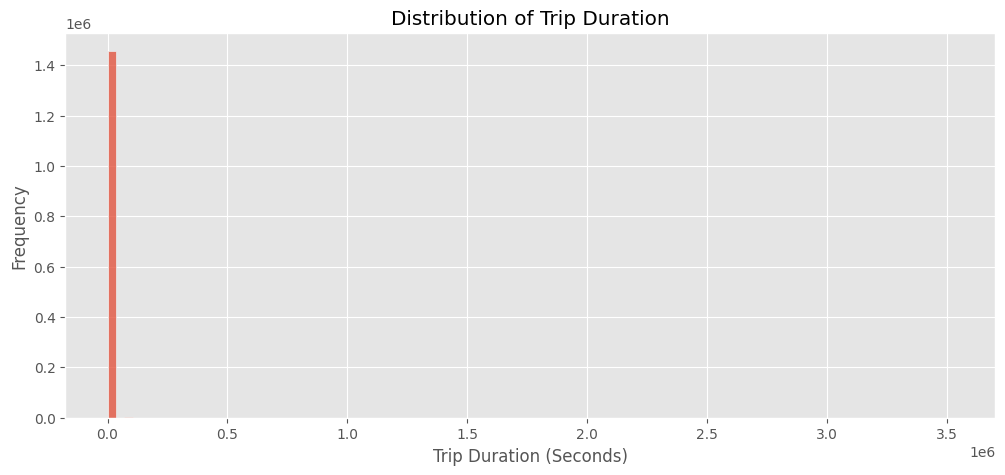

In [13]:
plt.figure(figsize=(12,5))

sns.histplot(train_df["trip_duration"], bins=100)

plt.title("Distribution of Trip Duration")

plt.xlabel("Trip Duration (Seconds)")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of trip duration is heavily right-skewed.

Most taxi trips are completed within a relatively short duration, while a small number of trips have extremely large durations.

These unusually long trips may represent outliers or rare real-world cases.

Further investigation is required before deciding whether these observations should be removed.

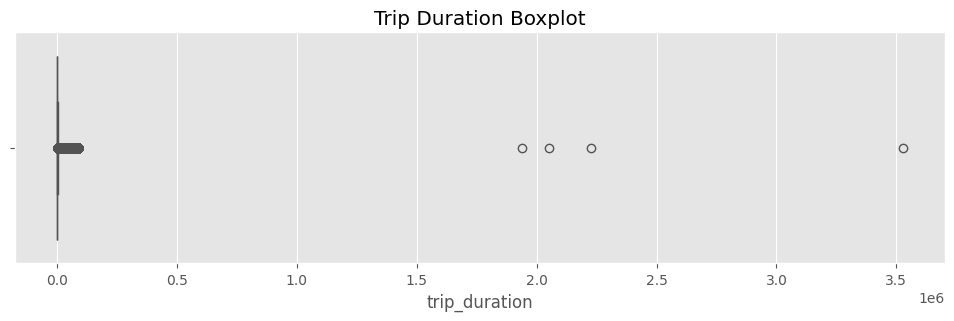

In [14]:
plt.figure(figsize=(12,3))

sns.boxplot(x=train_df["trip_duration"])

plt.title("Trip Duration Boxplot")

plt.show()

### Observation

The boxplot confirms the presence of extreme outliers in the target variable.

Outlier treatment will be performed during the Data Preprocessing stage rather than immediately removing observations during EDA.

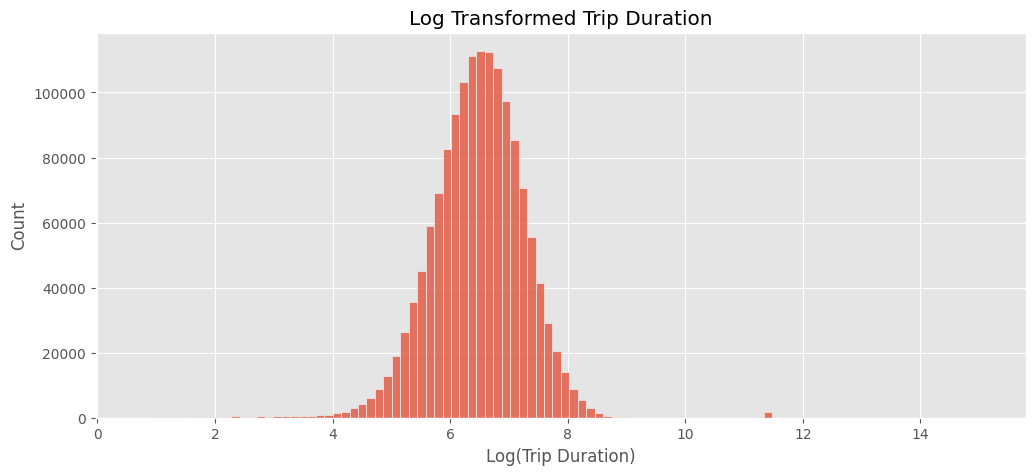

In [15]:
plt.figure(figsize=(12,5))

sns.histplot(np.log1p(train_df["trip_duration"]), bins=100)

plt.title("Log Transformed Trip Duration")

plt.xlabel("Log(Trip Duration)")

plt.show()

### Observation

Applying a logarithmic transformation significantly reduces skewness.

This suggests that log transformation may improve regression model performance and will be considered during preprocessing.

# Passenger Count Analysis

### Business Question

How many passengers usually travel in a taxi?

Passenger count may influence trip duration and therefore deserves further investigation.

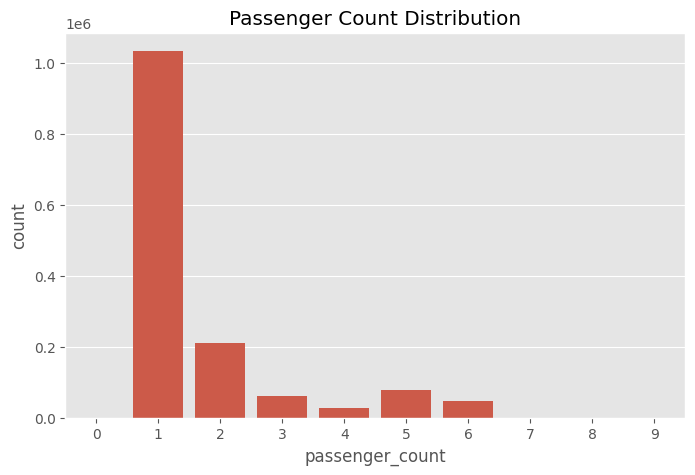

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="passenger_count",
    order=train_df["passenger_count"].value_counts().sort_index().index
)

plt.title("Passenger Count Distribution")

plt.show()

### Observation

The majority of taxi trips involve a single passenger.

Passenger counts between 2 and 4 are also common.

Passenger count equal to zero appears in the dataset and represents an invalid observation that will be removed during preprocessing.

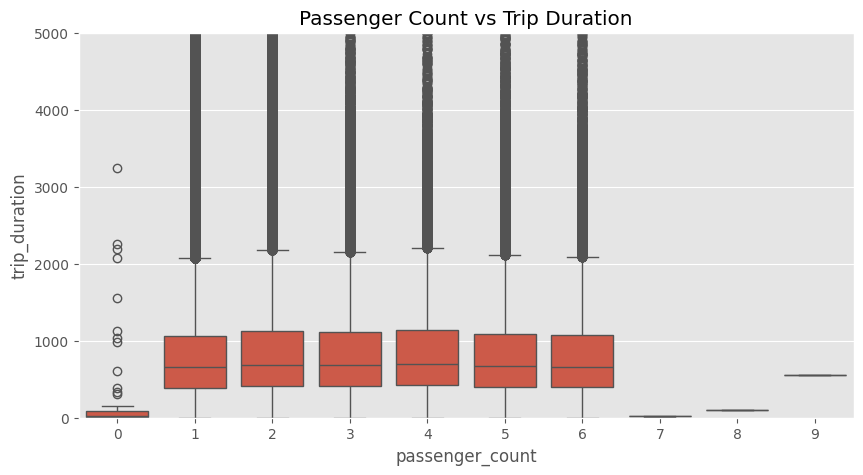

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train_df,
    x="passenger_count",
    y="trip_duration"
)

plt.ylim(0,5000)

plt.title("Passenger Count vs Trip Duration")

plt.show()

### Observation

Most passenger groups exhibit similar trip duration distributions.

Passenger count does not appear to have a strong direct influence on trip duration.

However, invalid passenger counts should still be cleaned before model training.

# Vendor Analysis

### Business Question

Do both taxi vendors contribute equally to the dataset, and does vendor type affect trip duration?

In [18]:
train_df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

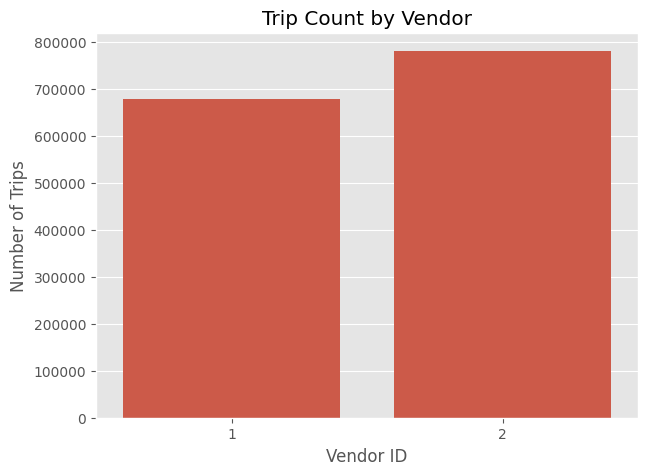

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(data=train_df, x="vendor_id")

plt.title("Trip Count by Vendor")
plt.xlabel("Vendor ID")
plt.ylabel("Number of Trips")

plt.show()

### Observation

Both vendors have a large number of trips in the dataset.

Vendor ID may be useful as a categorical feature, but further analysis is needed to understand whether trip duration differs across vendors.

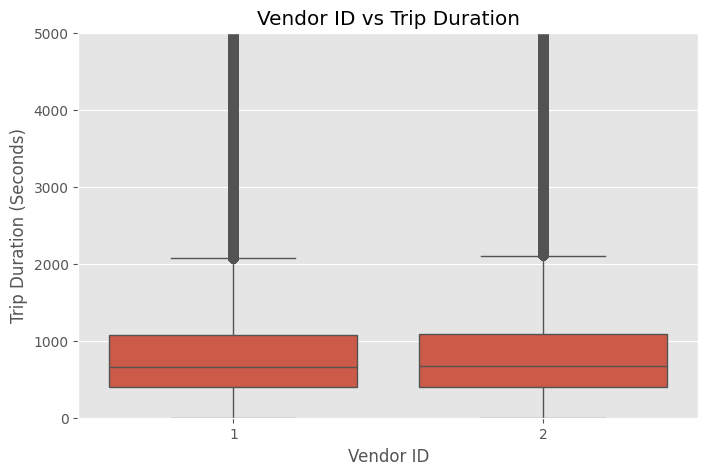

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train_df,
    x="vendor_id",
    y="trip_duration"
)

plt.ylim(0, 5000)

plt.title("Vendor ID vs Trip Duration")
plt.xlabel("Vendor ID")
plt.ylabel("Trip Duration (Seconds)")

plt.show()

### Observation

The trip duration distributions for both vendors appear broadly similar.

This suggests that vendor ID may not be the strongest predictor on its own, but it can still be retained for model training.

# Store and Forward Flag Analysis

### Business Question

How common are store-and-forward trips, and do they behave differently from regular trips?

In [21]:
train_df["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

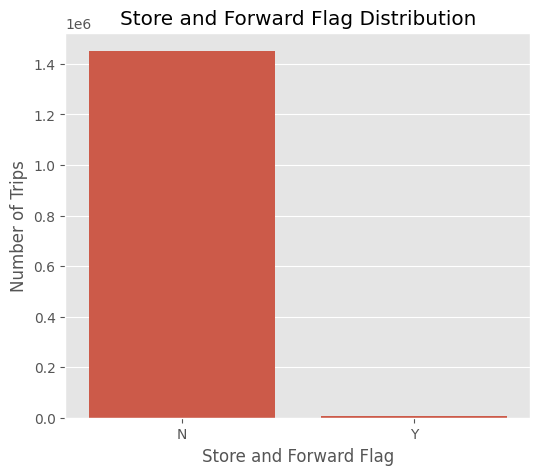

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(data=train_df, x="store_and_fwd_flag")

plt.title("Store and Forward Flag Distribution")
plt.xlabel("Store and Forward Flag")
plt.ylabel("Number of Trips")

plt.show()

### Observation

Most records have `store_and_fwd_flag = N`.

This means most trip records were sent directly to the server rather than being temporarily stored before forwarding.

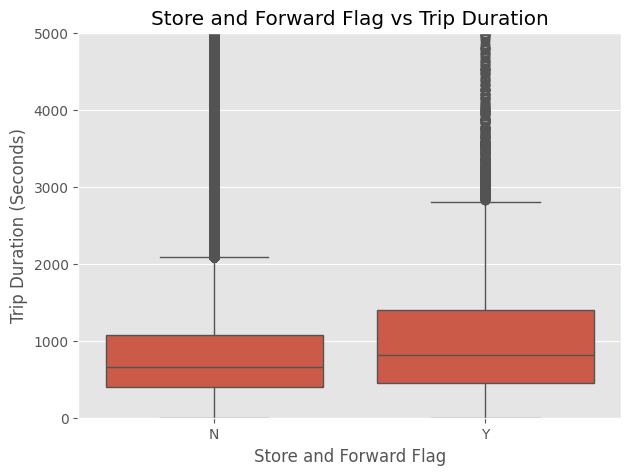

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train_df,
    x="store_and_fwd_flag",
    y="trip_duration"
)

plt.ylim(0, 5000)

plt.title("Store and Forward Flag vs Trip Duration")
plt.xlabel("Store and Forward Flag")
plt.ylabel("Trip Duration (Seconds)")

plt.show()

### Observation

The store-and-forward flag is highly imbalanced.

Even if the feature has limited direct impact, it will be encoded during preprocessing because machine learning models require numerical input.

# Datetime Analysis

### Business Question

How does taxi demand vary by time?

Taxi trip duration is often influenced by traffic patterns, rush hours, weekdays, weekends, and monthly travel behavior.

In [24]:
train_df["pickup_datetime"] = pd.to_datetime(train_df["pickup_datetime"])
train_df["dropoff_datetime"] = pd.to_datetime(train_df["dropoff_datetime"])

In [25]:
train_df["pickup_hour"] = train_df["pickup_datetime"].dt.hour
train_df["pickup_day"] = train_df["pickup_datetime"].dt.day
train_df["pickup_month"] = train_df["pickup_datetime"].dt.month
train_df["pickup_weekday"] = train_df["pickup_datetime"].dt.day_name()

### Note

The datetime features created here are used only for EDA.

Final feature engineering will be performed separately in the Feature Engineering notebook.

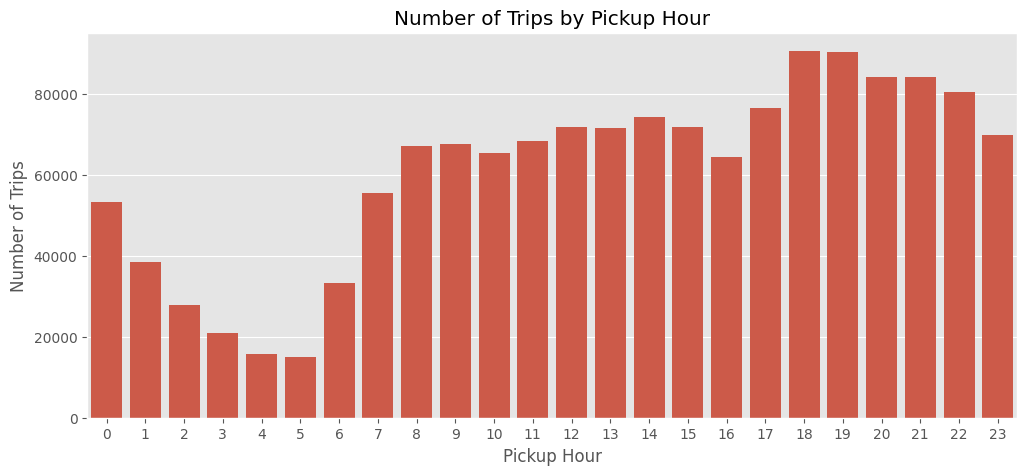

In [26]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=train_df,
    x="pickup_hour",
    order=sorted(train_df["pickup_hour"].unique())
)

plt.title("Number of Trips by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")

plt.show()

### Observation

Taxi demand changes throughout the day.

Pickup hour is likely to be an important feature because it can capture traffic patterns, commuting behavior, and nightlife-related trips.

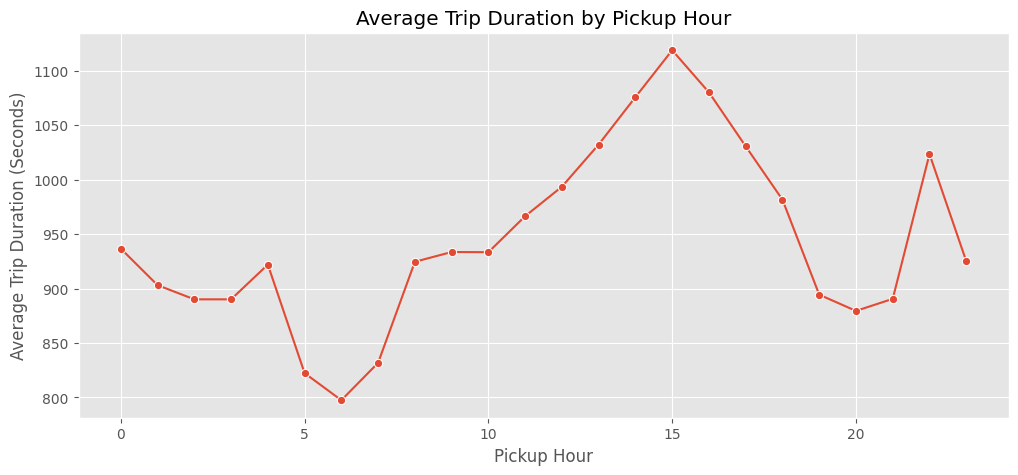

In [27]:
hourly_duration = train_df.groupby("pickup_hour")["trip_duration"].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_duration,
    x="pickup_hour",
    y="trip_duration",
    marker="o"
)

plt.title("Average Trip Duration by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (Seconds)")

plt.show()

### Observation

Average trip duration varies by hour of the day.

This supports the idea that traffic conditions and time of travel influence trip duration.

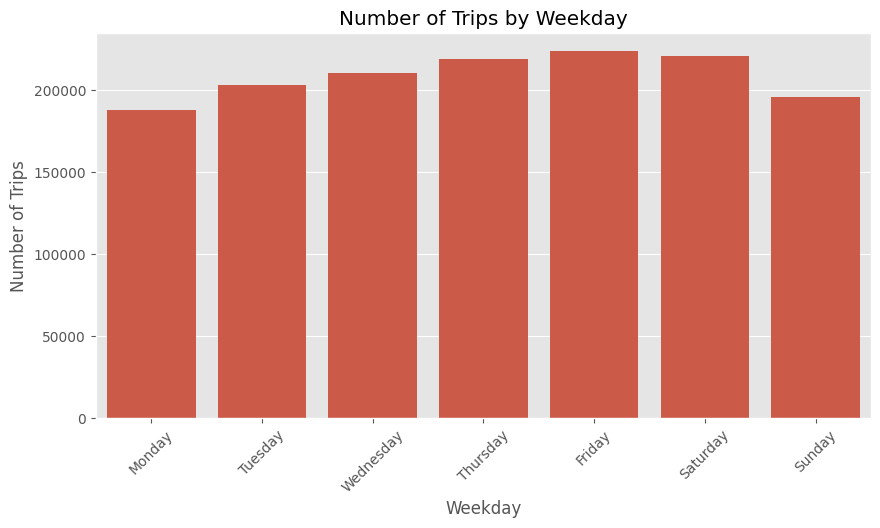

In [28]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x="pickup_weekday",
    order=weekday_order
)

plt.title("Number of Trips by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)

plt.show()

### Observation

Trip demand varies across weekdays.

Weekday information may help the model learn weekly travel behavior.

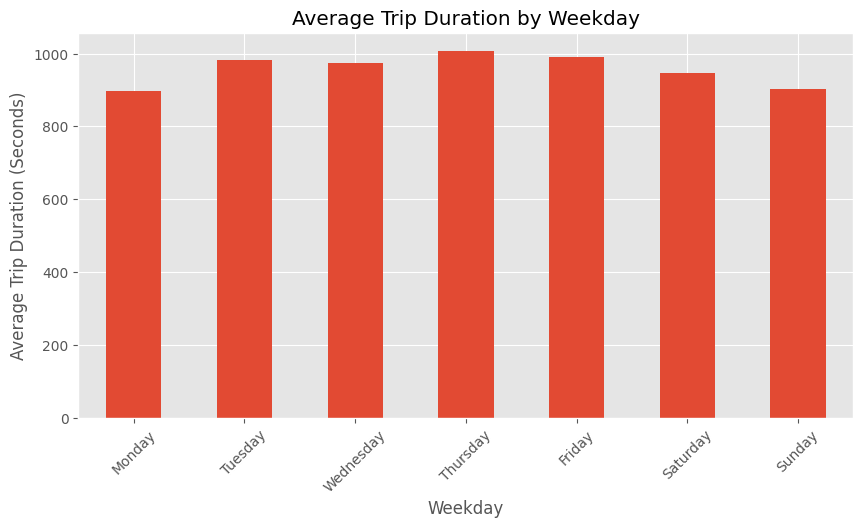

In [29]:
weekday_duration = train_df.groupby("pickup_weekday")["trip_duration"].mean().reindex(weekday_order)

plt.figure(figsize=(10,5))

weekday_duration.plot(kind="bar")

plt.title("Average Trip Duration by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Trip Duration (Seconds)")
plt.xticks(rotation=45)

plt.show()

### Observation

Average trip duration differs across weekdays.

This suggests that weekday-based features may improve prediction performance.

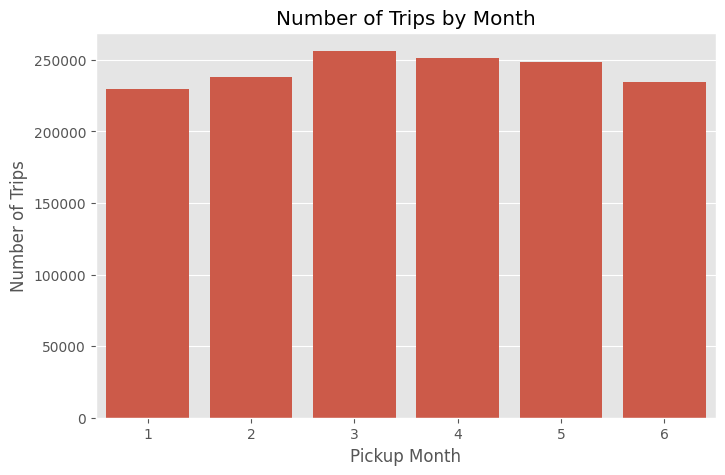

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="pickup_month",
    order=sorted(train_df["pickup_month"].unique())
)

plt.title("Number of Trips by Month")
plt.xlabel("Pickup Month")
plt.ylabel("Number of Trips")

plt.show()

### Observation

The dataset covers trips across multiple months.

Monthly patterns may capture seasonal or dataset-period-related variation.

# Geographic Analysis

## Business Question

Where do taxi trips originate and end?

Geographical analysis helps us identify trip hotspots, detect invalid GPS coordinates, and understand travel patterns across New York City.

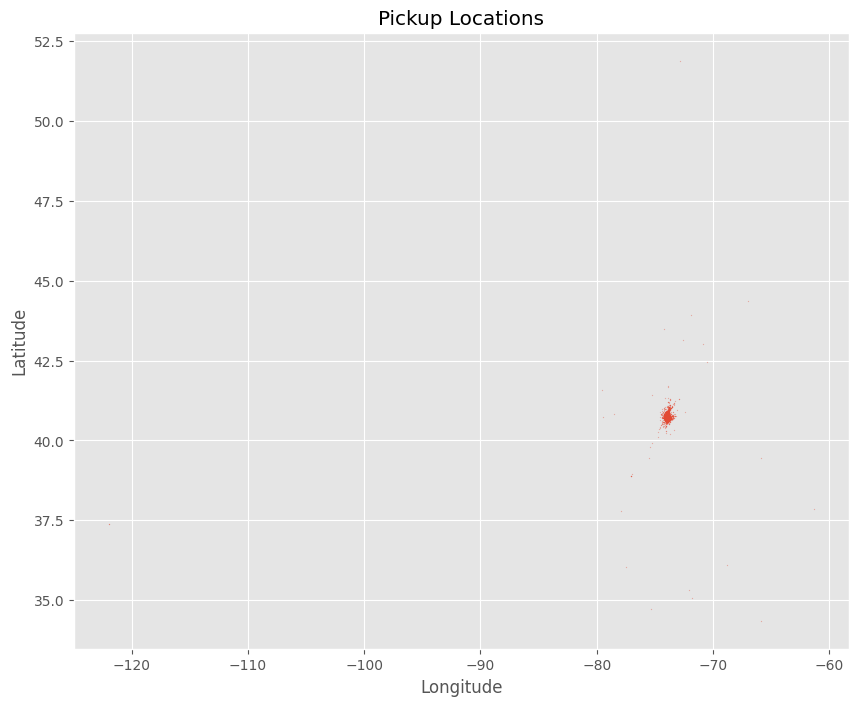

In [31]:
plt.figure(figsize=(10,8))

plt.scatter(
    train_df["pickup_longitude"],
    train_df["pickup_latitude"],
    s=0.2,
    alpha=0.3
)

plt.title("Pickup Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Observation

Most pickup locations are concentrated around New York City.

However, a few observations lie far outside the expected region, indicating potential GPS anomalies.

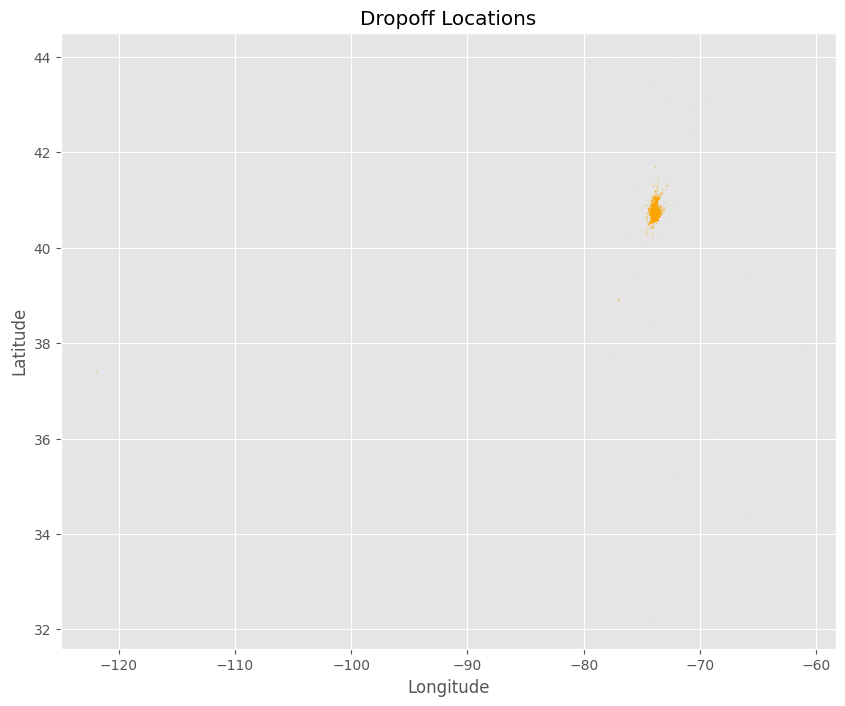

In [32]:
plt.figure(figsize=(10,8))

plt.scatter(
    train_df["dropoff_longitude"],
    train_df["dropoff_latitude"],
    s=0.2,
    alpha=0.3,
    color="orange"
)

plt.title("Dropoff Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Observation

Dropoff locations exhibit a similar geographical distribution.

The majority of trips occur within the New York City region, while a small number of records appear to contain invalid coordinates.

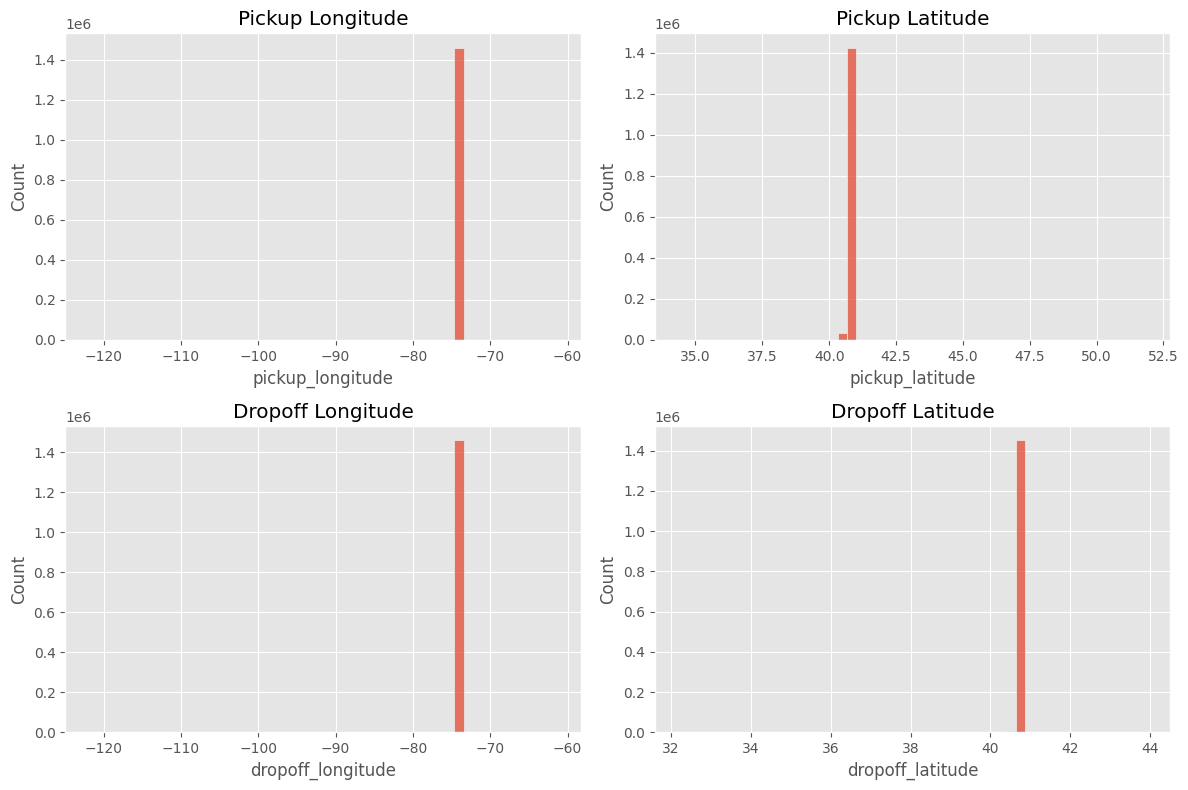

In [33]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

sns.histplot(train_df["pickup_longitude"], ax=ax[0,0], bins=50)
ax[0,0].set_title("Pickup Longitude")

sns.histplot(train_df["pickup_latitude"], ax=ax[0,1], bins=50)
ax[0,1].set_title("Pickup Latitude")

sns.histplot(train_df["dropoff_longitude"], ax=ax[1,0], bins=50)
ax[1,0].set_title("Dropoff Longitude")

sns.histplot(train_df["dropoff_latitude"], ax=ax[1,1], bins=50)
ax[1,1].set_title("Dropoff Latitude")

plt.tight_layout()
plt.show()

### Observation

The coordinate distributions are highly concentrated around New York City.

A few extreme values exist, suggesting GPS errors that will be addressed during preprocessing.